In [1]:
import zeus21
import eMCMC
import estats
from matplotlib.ticker import MaxNLocator
import eplots
Plotting = eplots.Plotting()
import importlib

In [2]:
# Get data
datBouw21 = np.loadtxt('/Users/eb35267/Desktop/research/data/Bouwens2021_GAL.txt',  skiprows=2, unpack=True)
redshiftsBouw21 = np.unique(datBouw21[0])
dredshiftsBouw21 = np.ones_like(redshiftsBouw21)/2. #approximate, there are true window functions to use

datHST = [] 
#format is     zdat = data[0] zerr = data[1] xdat = data[2],  ydat = data[3]  yerr = data[4]  xerr = data[5] 

for iz,z in enumerate(redshiftsBouw21): # Create a bunch of arrays that contain all of the data listed above. One for each redshift
    zlistindex = datBouw21[0] == 1.0*z
    datarr = [z,dredshiftsBouw21[iz], datBouw21[1][zlistindex], datBouw21[3][zlistindex], datBouw21[4][zlistindex], datBouw21[2][zlistindex]]
    datHST= datHST + [datarr]

# Gelli+24 comparison

## Run a fit at $z=5$ to estimate the parameters used

In [15]:
# Set hyperparameters
# Metadata table
custom_params = None
param_data = eMCMC.build_param_data(custom_params)

"""
Scale is an array that describes the factor to scale each parameter has been multiplied by. The reason for multiplying some parameters by 
a scale factor is because some have best fit values that are very small (e.g. 0.01), especially the time-evolution parameters. Scaling
them up (by multiplying by 100 in this case) allows steps in each parameter to have the same order of magnitude (e.g. 1)
"""

'\nScale is an array that describes the factor to scale each parameter has been multiplied by. The reason for multiplying some parameters by \na scale factor is because some have best fit values that are very small (e.g. 0.01), especially the time-evolution parameters. Scaling\nthem up (by multiplying by 100 in this case) allows steps in each parameter to have the same order of magnitude (e.g. 1)\n'

In [16]:
# Initalize class to test just the mass dependence
my_UVLF = eMCMC.UVLF(datHST[1], param_data)

In [17]:
# Get initial positions for all the walkers by running a short MCMC
ICs = my_UVLF.generate_ICs()

In [18]:
# Run MCMC
Nsteps=2000
my_UVLF.sampler.run_mcmc(ICs, Nsteps) 
# Get flat sample from the MCMC
samples = my_UVLF.sampler.get_chain(discard = 400, flat=True)

In [19]:
corner = Plotting.plot_corner(samples, param_data)

AttributeError: 'dict' object has no attribute 'param_data'

In [ ]:
ev_sig = Plotting.plot_evolving_UVLF_fit(samples, my_UVLF, title = '')
#ev_sig.savefig('/Users/eb35267/Desktop/figures/ongoing/Gelli_comparison/tuning_parameters_z5Bouwens.png', bbox_inches = 'tight')

# Proving that sigma(M) is working

In [31]:
z = datHST[0][0]
zwidth = datHST[0][1]
MUVcenters = datHST[0][2]
MUVwidth = datHST[0][5]
ydat = datHST[0][3]
yerr = datHST[0][4]

In [32]:
CosmoParams_input = zeus21.Cosmo_Parameters_Input(zmin_CLASS=0.0)
CosmoParams, _, _, HMFintclass =  zeus21.cosmo_wrapper(CosmoParams_input)

In [201]:
evolv_sigUV = (1 + (.5*(np.log10(HMFintclass.Mhtab)-11)))
evolv_sigUV = np.maximum(evolv_sigUV, 0)
astroparams_test = zeus21.Astro_Parameters(CosmoParams,epsstar=10**params1[3], Mc=10**params1[0],alphastar=params1[1], betastar=params1[2], 
                                      sigmaUV = evolv_sigUV)
UVLF_test = zeus21.UVLFs.UVLF_binned(astroparams_test,CosmoParams,HMFintclass,z,zwidth,MUVcenters,MUVwidth)

In [202]:
astroparams_std = zeus21.Astro_Parameters(CosmoParams,epsstar=10**params1[3], Mc=10**params1[0],alphastar=params1[1], betastar=params1[2], 
                                      sigmaUV = 1) 
UVLF_std = zeus21.UVLFs.UVLF_binned(astroparams_std,CosmoParams,HMFintclass,z,zwidth,MUVcenters,MUVwidth)

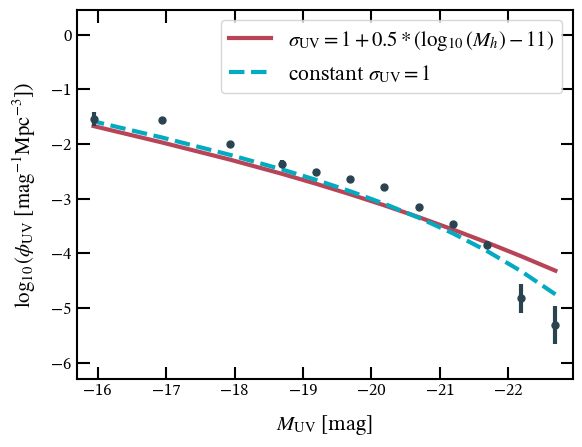

In [205]:
fig, ax = plt.subplots()

ax.plot(MUVcenters, np.log10(UVLF_test), label = r'$\sigma_{\rm{UV}} = 1 + 0.5*(\log_{10}(M_h) - 11)$' )
ax.plot(MUVcenters, np.log10(UVLF_std), label = r'constant $\sigma_{\rm{UV}} = 1$', linestyle = '--')


ax.set_ylim(np.log10(np.min(ydat))-1, np.log10(np.max(ydat))+2)

ax.errorbar(MUVcenters, np.log10(ydat), estats.calc_log_error(ydat, yerr), fmt = ".", capsize=0, markersize = 10, 
               color = Plotting.navy)
ax.invert_xaxis()
ax.set_xlim(np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25)
ax.xaxis.set_major_locator(MaxNLocator(integer=True)) # Make it so that only integers can be used in the axis labels

ax.set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')

ax.legend()

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/sigma(M_h).png', bbox_inches = 'tight')